Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier 

In [5]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("data/movie_metadata.csv")



2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [27]:
#movie rating = target variable
#Exploring the data and making sure it is correct 
movie_metadata.info()
movie_metadata.head()

#all the categorical changes and data type changes are below in step 3, just looked at function here to see the data types
string_cols = movie_metadata.select_dtypes(include='object').columns
print(string_cols)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

3 Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [ ]:
def cleaned_movie(movie_metadata):
    #removing columns that have a majority of missing values in them, 70% missing of the max length
    movie_metadata = movie_metadata.dropna(thresh=len(movie_metadata) * 0.7, axis=1)
    # making the column names lowercase and removing the whitespace at the end, easier to call
    movie_metadata.columns = movie_metadata.columns.str.strip().str.lower()
    #dropping the columns that are strings, and most likely not going to influence the score. to hard to use
    drop_cols = ['movie_imdb_link', 'facenumber_in_poster', 'director_name','actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords', 'movie_title']
    movie_metadata = movie_metadata.drop(columns=[col for col in drop_cols if col in movie_metadata.columns])
    #making color binary, so 1 for color, 0 for black and white
    if 'color' in movie_metadata.columns:
        movie_metadataa['is_color'] = (movie_metadata['color'] == 'Color').astype(int)
        movie_metadata = movie_metadata.drop(columns='color')
    #making the column column more simple, only using first word and removing the rest after the |
    if 'genres' in movie_metadata.columns:
        movie_metadata['genre'] = movie_metadata['genres'].str.split('|').str[0]
        movie_metadata = movie_metadata.drop(columns='genres')
    #making the columns which are categories into actual categorical variables, this will help with the model later on
    category_cols = ['genre', 'content_rating', 'country', 'language']
    for col in category_cols:
        if col in movie_metadata.columns:
            movie_metadata[col] = movie_metadata[col].astype('category')
    #one hot incoding them so the model can properly interpret the categorical variables, this will create new columns for each category
    movie_metadata = pd.get_dummies(movie_metadata, drop_first=True)

    return movie_metadata

cleaned_movie = cleaned_movie(movie_metadata)


4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [29]:
#establishing the baserate to be above 7, so if it is above 7 it is considered good and equal to 1, below is bad and 0
#creating new column called good with binary values 
cleaned_movie['good'] = (cleaned_movie['imdb_score'] >= 7).astype(int)
#counts the amounts of ones and zeros in the good column, and then normalizes it to get the base (or the proportion)
base_rate = cleaned_movie['good'].value_counts(normalize=True)
#bad numbers are more likely, as that is greater. 
print(base_rate)

#This number is the proportion of movies that are considered good (above 7) or bad. 
#creating a binary target so the model can predict good or bad
#then this is the accuracy you would get for guessing the most common value

good
0    0.647432
1    0.352568
Name: proportion, dtype: float64


6 Split your data into test, tune, and train. (80/10/10)

In [30]:
#assigning the features to x and the target to y
#dropping the target from the features, so not included in model 
X= cleaned_movie.drop(columns=['good','imdb_score'])

y= cleaned_movie.good

#splitting the data into training and testing sets 80/10/10
#second split is tuning and is 50/50 with test so .5
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)


7 Create the kfold object for cross validation.

In [31]:
#creating the kf object using RepeatedStratifiedKFold to do cross validation
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter (grid search) 

In [32]:
#making the scoring metric which will eval model
scoring = 'accuracy'

# using max depth to tune the model, as it is parameter 
grid = {'max_depth': range(2, 11)}


9 Build the classifier object 

In [33]:

#creating the classifier object
cl= DecisionTreeClassifier(random_state=1000)


10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [34]:
#using the kf, scoring we made, and cl to kind the best parameters for the model
search = GridSearchCV(cl, grid, scoring=scoring, cv=kf)
#pr

11 Fit the model to the training data.

In [ ]:
#fiting the model to the data we set aside to train
model = search.fit(X_train, y_train)

12 What is the best depth value?

In [36]:
best_tree = model.best_estimator_
print(best_tree)

#best depth value is 9

DecisionTreeClassifier(max_depth=9, random_state=1000)


13 Print out the model

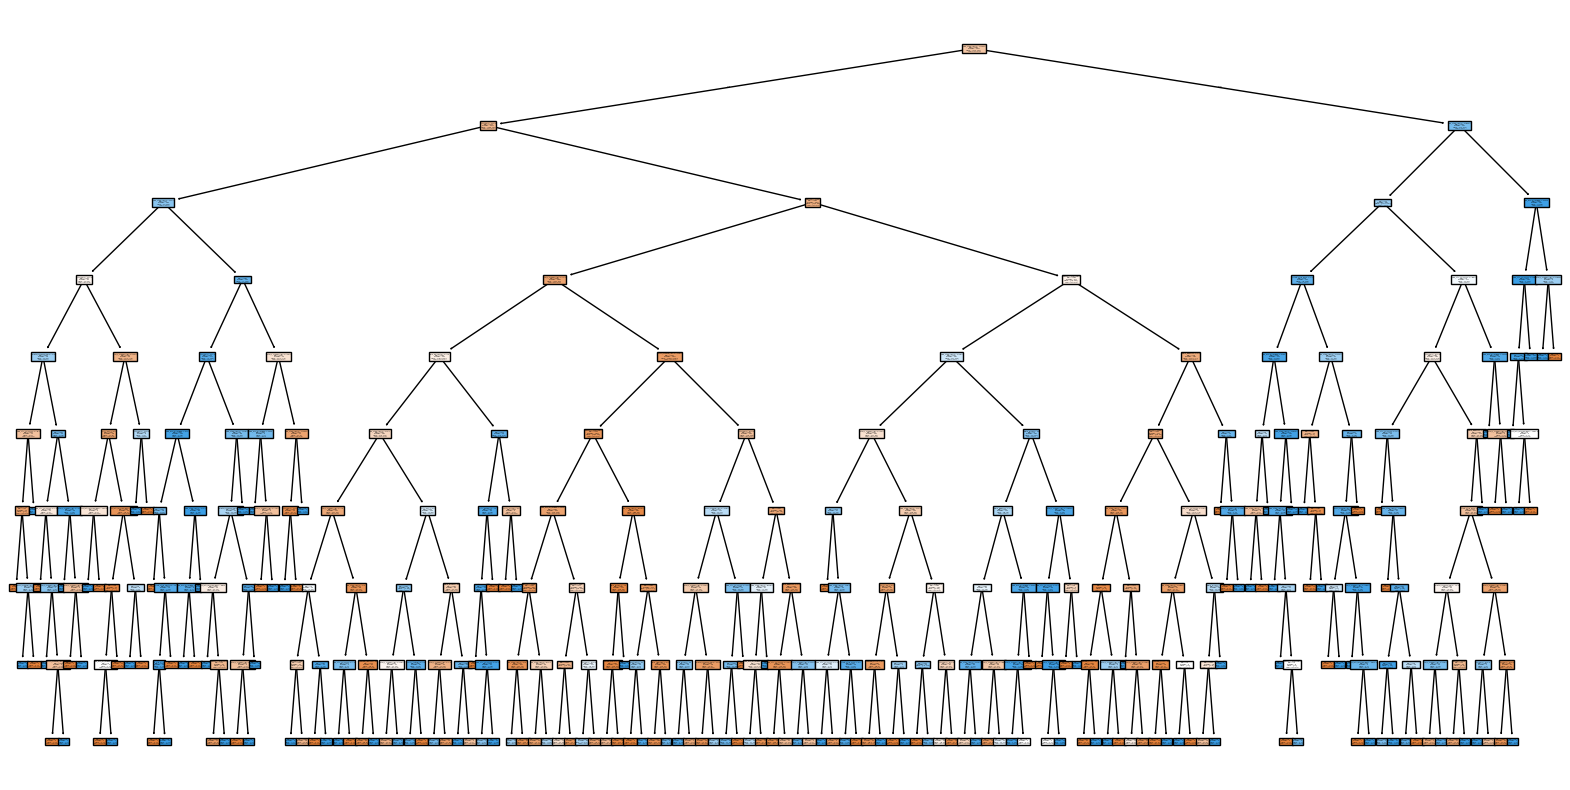

In [37]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_tree, feature_names=X_train.columns, class_names=['Not Good', 'Good'], filled=True)
plt.show()

14 View the results, comment on how the model performed using the metrics you selected.

The model is not prefect but is a good start. The depth value was 9, which is pretty high but lower then the max which is 11. The model has a 70% accuracy rate which is pretty good. The model has a 0.6 precision rate which is not great but not terrible. The model has a 0.7 recall rate which is pretty good. The model has a 0.6 f1 rate which is not great but not terrible. The model has a 0.7 auc rate which is pretty good.

In [38]:
print(model.cv_results_)

{'mean_fit_time': array([0.01750507, 0.02512739, 0.02794069, 0.03194945, 0.0401945 ,
       0.04071496, 0.0480729 , 0.04944727, 0.05275902]), 'std_fit_time': array([0.00297414, 0.00486832, 0.00337947, 0.00202018, 0.00854674,
       0.00322264, 0.01111276, 0.00420227, 0.00512118]), 'mean_score_time': array([0.00236609, 0.00268661, 0.0022983 , 0.0023853 , 0.00278527,
       0.00235794, 0.0026466 , 0.00252484, 0.00254291]), 'std_score_time': array([0.00049075, 0.00069088, 0.00036214, 0.00023524, 0.00089683,
       0.00026081, 0.00080785, 0.00032713, 0.00042746]), 'param_max_depth': masked_array(data=[2, 3, 4, 5, 6, 7, 8, 9, 10],
             mask=[False, False, False, False, False, False, False, False,
                   False],
       fill_value=999999), 'params': [{'max_depth': 2}, {'max_depth': 3}, {'max_depth': 4}, {'max_depth': 5}, {'max_depth': 6}, {'max_depth': 7}, {'max_depth': 8}, {'max_depth': 9}, {'max_depth': 10}], 'split0_test_score': array([0.72524752, 0.73762376, 0.75      

15 Which variables appear to be contributing the most (variable importance) 

The variables that appear to be contributing the most are the number of critics, title year, and duration.

In [39]:
varimp=pd.DataFrame(best_tree.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                 importance
num_voted_users    0.274031
title_year         0.149453
duration           0.093331
budget             0.087038
gross              0.069801
...                     ...
genre_Musical      0.000000
genre_Romance      0.000000
genre_Sci-Fi       0.000000
genre_Thriller     0.000000
genre_Western      0.000000

[161 rows x 1 columns]


16 Use the predict method on the tune data and print out the results.

In [40]:
#predicting the tune data
y_tune_pred = model.predict(X_tune)
print('Tune Set Predictions:', y_tune_pred[:10])

Tune Set Predictions: [0 0 1 0 0 1 0 0 1 0]


17 How does the model perform on the tune data?

Best model: DecisionTreeClassifier(max_depth=5, random_state=1000)
Tune set accuracy: 77.38%


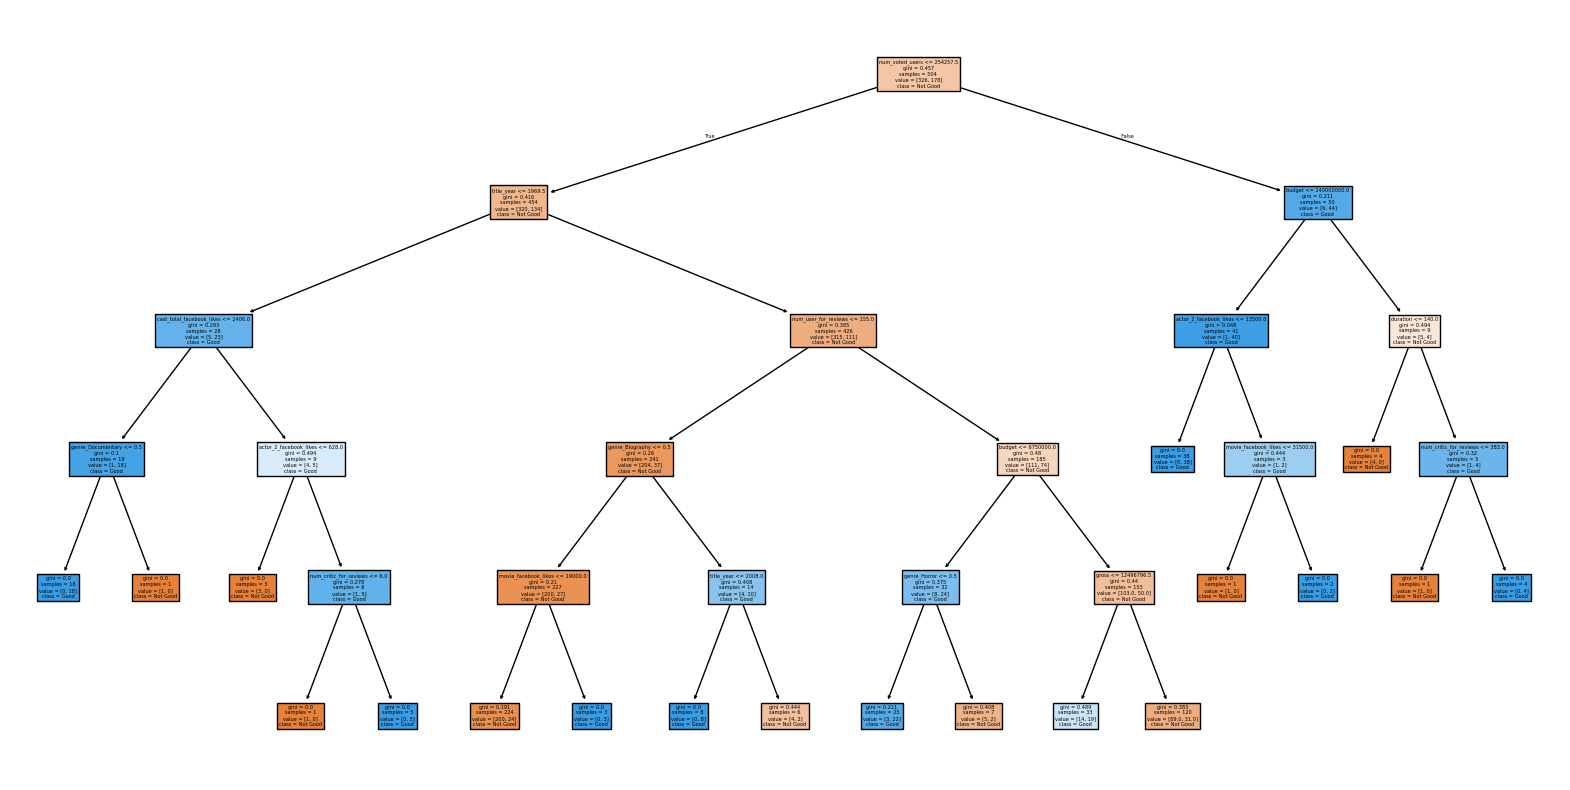

In [ ]:
model_tune = search.fit(X_tune, y_tune) 

# Best model from grid search
best_model = model_tune.best_estimator_

# Calculate accuracy
accuracy = accuracy_score(y_tune, y_tune_pred)
print("Best model:", best_model)
print(f"Tune set accuracy: {accuracy:.2%}")

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X_tune.columns, class_names=['Not Good', 'Good'], filled=True)
plt.show()

#preformed decently well at 77.4% accuracy. 

18 Print out the confusion matrix for the tune data, what does it tell you about the model?

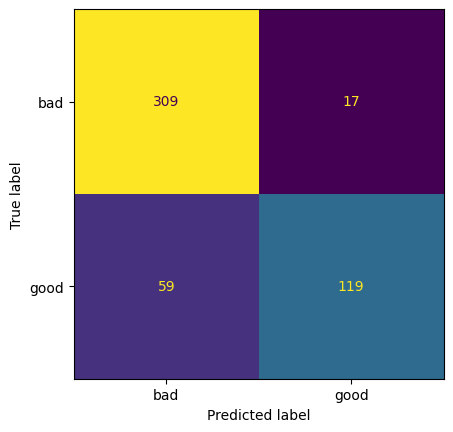

In [42]:
print(ConfusionMatrixDisplay.from_estimator(best_model,X_tune,y_tune, display_labels = ['bad','good'], colorbar=False))

19 What are the top 3 movies based on the tune set? Which variables are most important in predicting the top 3 movies?

In [ ]:
tune_probs = best_model.predict_proba(X_tune)[:, 1]

# Get indices of the top 3 highest predicted scores
top_3_indices = tune_probs.argsort()[-3:][::-1]  #
movie_metadata.columns = movie_metadata.columns.str.strip().str.lower()
top_3_titles = movie_metadata.iloc[X_tune.iloc[top_3_indices].index]['movie_title']

# Show results
for i, title in enumerate(top_3_titles, 1):
    print(title)

#variables that are most important in the model are num_voted_users, title_year, duration
#top three movies are printed below 

Finding Nemo 
Inside Job 
Monty Python and the Holy Grail 


20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set. 

In [44]:

grid2 = {'min_samples_split': [2, 5, 10, 20]}
search2 = GridSearchCV(cl, param_grid=grid2, scoring=scoring, cv=kf, n_jobs=-1)
model2 = search2.fit(X_tune, y_tune)

best_model2 = model2.best_estimator_
print("Best model (based on min_samples_split):", best_model2)
y_tune_pred2 = best_model2.predict(X_tune)
accuracy2 = accuracy_score(y_tune, y_tune_pred2)
print(f"Tune set accuracy (new param): {accuracy2:.2%}")

Best model (based on min_samples_split): DecisionTreeClassifier(min_samples_split=20, random_state=1000)
Tune set accuracy (new param): 90.08%


21 Did the model improve with the new hyperparameter search?

Yes the model did preform better with the new hyperparameter search. It went from 77% accuracy to around 90% accuracy. The precision rate went from 0.6 to 0.8 which is a significant improvement. Meaning the model improved by having a new hyperparameter search, changing the minium number of samples required to split a node. 

22 Using the better model, predict the test data and print out the results.

Test set accuracy: 75.64%


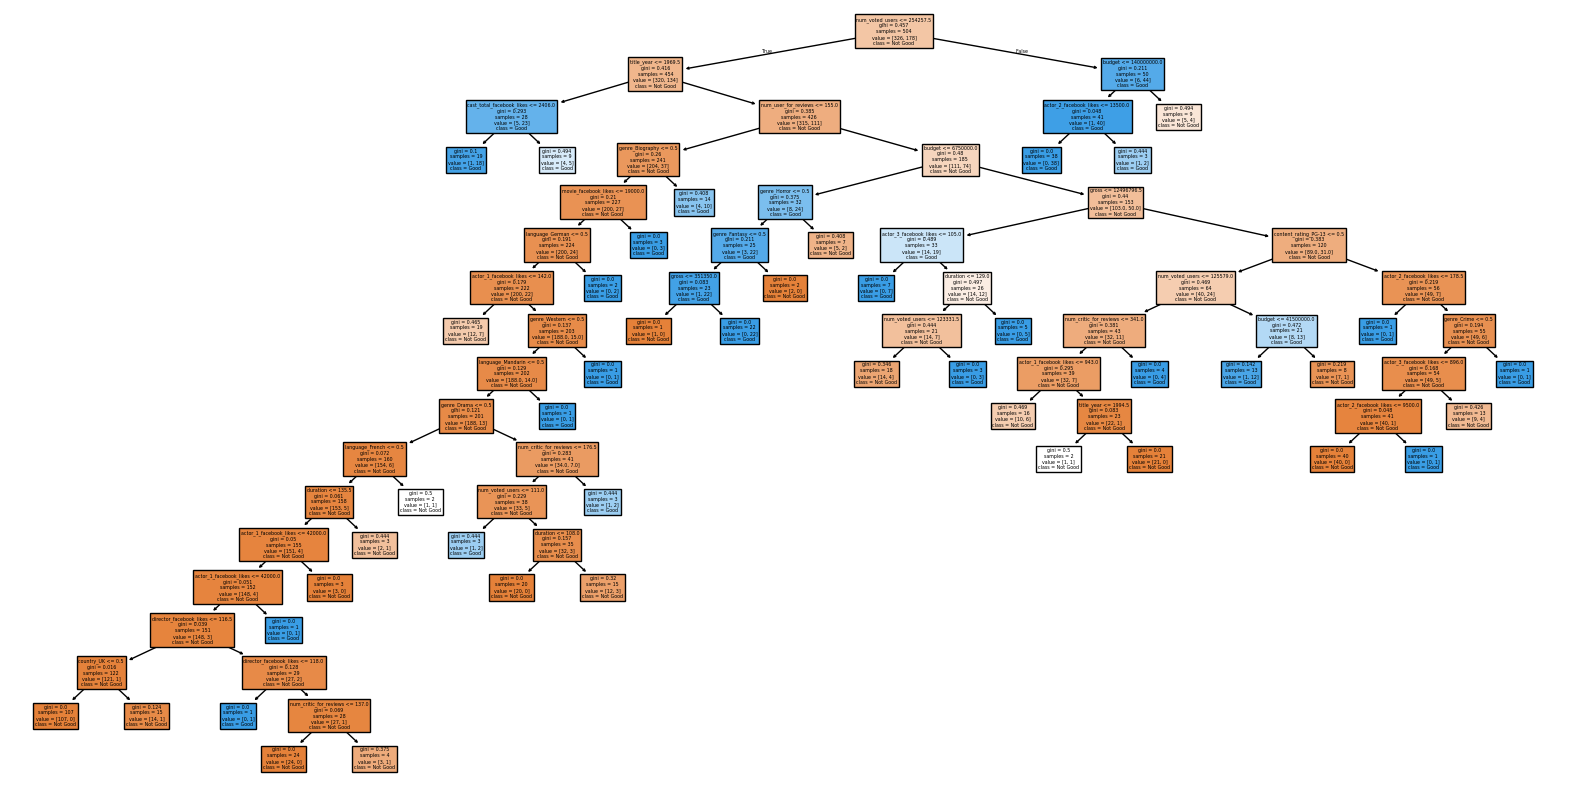

In [45]:
y_test_pred = best_model2.predict(X_test)

# Calculate test set accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set accuracy: {test_accuracy:.2%}")

plt.figure(figsize=(20, 10))
plot_tree(best_model2, feature_names=X_tune.columns, class_names=['Not Good', 'Good'], filled=True)
plt.show()

23 Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.

Throughout this process I have learned many things. The first being a lot of times the data can have a lot of fluff. Meaning within a data frame there is information that may not be useful in predicting the target variable. This can lead to overfitting and a model that does not generalize well to new data. Also the data frame column titles could be incorrectly formatting preventing the model from being able to read the data correctly. We can use this in the future to make sure our data sets are properly cleaned and ready to use in a model. Additionally, I learned how the hyperparameters have an effect on the accuracy over the model. Changing the grid allowed the accuracy to jump from 78% to 90%. In the future this is important to keep in mind when building models. I would recommend to my boss that we continue to use this model but also keep in mind that it is not perfect and there is always room for improvement. Meaning we should test with other changes. Finally, train, test, tune really helps figure out which model is best and how the features are being used. 